In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statistical test
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv("ab_data.csv")

In [4]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [5]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 23.0 MB


In [7]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [8]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [9]:
df["user_id"].duplicated().sum()

np.int64(3894)

In [10]:
df[df["user_id"].duplicated()].head()

,user_id,timestamp,group,landing_page,converted
2656,698120,2017-01-15 17:13:42.602796,control,old_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0
7500,899953,2017-01-07 03:06:54.068237,control,new_page,0
8036,790934,2017-01-19 08:32:20.329057,treatment,new_page,0
10218,633793,2017-01-17 00:16:00.746561,treatment,old_page,0


In [11]:
df = df.drop_duplicates(subset="user_id", keep="first")

In [12]:
df["user_id"].duplicated().sum()

np.int64(0)

In [13]:
df.shape

(290584, 5)

In [14]:
df["group"].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [15]:
(df["group"].value_counts(normalize=True) * 100).round(2)

group
treatment    50.02
control      49.98
Name: proportion, dtype: float64

In [16]:
df["landing_page"].value_counts()

landing_page
new_page    145320
old_page    145264
Name: count, dtype: int64

In [17]:
df["converted"].value_counts()

converted
0    255839
1     34745
Name: count, dtype: int64

In [18]:
(df["converted"].value_counts(normalize=True) * 100).round(2)

converted
0    88.04
1    11.96
Name: proportion, dtype: float64

In [19]:
conversion = df.groupby("group")["converted"].mean() * 100
conversion.round(2)

group
control      12.03
treatment    11.88
Name: converted, dtype: float64

In [20]:
df["group"].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [21]:
(df["group"].value_counts(normalize=True) * 100).round(2)

group
treatment    50.02
control      49.98
Name: proportion, dtype: float64

In [22]:
df["landing_page"].value_counts()

landing_page
new_page    145320
old_page    145264
Name: count, dtype: int64

In [23]:
conversion = df.groupby("group")["converted"].mean() * 100
conversion.round(2)

group
control      12.03
treatment    11.88
Name: converted, dtype: float64

In [24]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,1006,144226
treatment,144314,1038


In [25]:
df = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
]

In [26]:
df.shape

(288540, 5)

In [27]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,0,144226
treatment,144314,0


In [28]:
conversion = df.groupby("group")["converted"].mean() * 100
conversion.round(2)

group
control      12.03
treatment    11.87
Name: converted, dtype: float64

In [29]:
df.shape

(288540, 5)

In [31]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,0,144226
treatment,144314,0


In [32]:
conversion.round(2)

group
control      12.03
treatment    11.87
Name: converted, dtype: float64

In [33]:
from scipy.stats import chi2_contingency

In [34]:
contingency = pd.crosstab(df["group"], df["converted"])
contingency

converted,0,1
group,,
control,126877,17349
treatment,127180,17134


In [35]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 1.6602265966517187
P-value: 0.19757273201400033


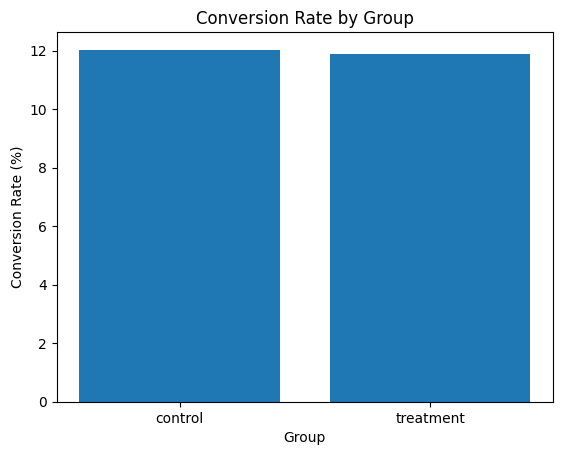

In [36]:
import matplotlib.pyplot as plt

plt.bar(conversion.index, conversion.values)
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.show()